# CD-A no-epoch: baseline vs mask/screening variants on ER graphs

Benchmarks `coordinate0.dag_coordinate_descent_l0` (cd_A_noepoch) against
`cd_A_weakfaith.dag_coordinate_descent_l0_weakfaith`.

Two independent experiments on the same ER / Gaussian data generator:

- **Section A — Mask / screening method comparison (fixed $\tau$).** Compare
  the dynamic `initial_gain` mask against single weak-faithfulness screens
  `corr`, `pcorr`, `glasso`, and only two combined screens:
  `corr+pcorr` and `corr+glasso`. Combined screens use
  `combine="intersect"`, i.e. an edge is masked when ANY selected screen
  marks it as zero (not the older "corr+pcorr 同为 0 才舍弃" rule).
- **Section B — $\tau$ sensitivity scan.** For a few representative screen
  configurations, vary $\tau$ across a range and measure its effect,
  isolating it from the choice of screen.

Design doc: `docs/weak_faithfulness_cd_A_noepoch_zh.md`.

Metrics: SHD, CPDAG-SHD, MEC match, runtime, actual steps (when
early-stopped), mask sparsity $M / d(d-1)$, per-screen zero counts,
initial-gain zero counts, and overlap diagnostics among the masked edge sets.

In [1]:
# 1) Environment and imports
import os
import sys
import time
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print('Python   :', sys.version.split()[0])
print('Repo root:', repo_root)

from MEC import is_in_markov_equiv_class, get_skeleton, find_v_structures
# Switched (2026-05): use CalmDataset (kaifeng-jin/CALM-compatible) instead
# of synthetic_dataset.SyntheticDataset, to align with the rest of the recent
# CALM-related benchmarks (Table 5 / Table 7 reproductions, noise_ratio sweep,
# standardize sweep, etc.). See `calm_dataset.py` for the data-generation chain.
from calm_dataset import CalmDataset
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_noepoch_fit
from coordinate_descent.cd_A_weakfaith import (
    dag_coordinate_descent_l0_weakfaith as cd_noepoch_weakfaith_fit,
    _build_faithfulness_mask,
    _build_initial_gain_mask,
    faithfulness_mask_diagnostics,
)

# Switched (2026-05): CPDAG-SHD now goes through dag_metrics.cpdag_shd,
# which uses the same causaldag.PDAG.shd implementation as the paper
# (kaifeng-jin/CALM metrics.compute_shd_cpdag). The previous path was
# cdt.metrics.SHD_CPDAG (often unimportable on Windows due to GPUtil) with
# a fallback to a manual skel+v-struct approximation that is systematically
# ~2.4x too large vs the paper number. dag_metrics handles both DAG and
# PDAG estimates (PC/FGES output undirected edges) automatically.
from dag_metrics import cpdag_shd as _cpdag_shd_dagmetrics, get_cpdag_shd_backend

print('cd_A baseline    : OK')
print('cd_A weakfaith   : OK')
print('CalmDataset      : OK')
print(f'CPDAG-SHD backend: {get_cpdag_shd_backend()}')

Python   : 3.10.11
Repo root: c:\Users\super\DAG
c:\Users\super\DAG\experiments\notebooks\test


C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cd_A baseline    : OK
cd_A weakfaith   : OK
CalmDataset      : OK
CPDAG-SHD backend: causaldag


In [2]:
# 2) Helpers
def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    """Thin wrapper around dag_metrics.cpdag_shd.

    Switched (2026-05) from the cdt.SHD_CPDAG path. dag_metrics goes
    through causaldag (same library as paper's compute_shd_cpdag) and
    auto-detects DAG vs PDAG (PDAG path used by PC/FGES; not relevant
    here since cd_A always produces a DAG, but kept for parity with
    other notebooks).
    """
    return _cpdag_shd_dagmetrics(G_true, G_est)


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    G_true = np.asarray(G_true, dtype=int)
    G_est = np.asarray(G_est, dtype=int)
    d, dist = G_true.shape[0], 0
    for i in range(d):
        for j in range(i + 1, d):
            if G_true[i, j] != G_est[i, j] or G_true[j, i] != G_est[j, i]:
                dist += 1
    return float(dist)


def make_row(d, n, trial_id, seed, alg, runtime_sec, G_true, G_est,
             actual_steps=None, mask_keep_ratio=None, extra=None):
    mec = int(is_in_markov_equiv_class(G_true, G_est))
    shd = shd_score(G_true, G_est)
    cshd = cpdag_shd_score(G_true, G_est)
    row = {
        'd': d,
        'n_samples': n,
        'trial_id': trial_id,
        'seed': seed,
        'algorithm': alg,
        'mec_match': mec,
        'shd': shd,
        'cpdag_shd': cshd,
        'n_edges_true': int(G_true.sum()),
        'n_edges_est': int(G_est.sum()),
        'runtime_sec': float(runtime_sec),
    }
    if actual_steps is not None:
        row['actual_steps'] = int(actual_steps)
    if mask_keep_ratio is not None:
        row['mask_keep_ratio'] = float(mask_keep_ratio)
    if extra:
        row.update(extra)
    return row


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame()
    agg_dict = dict(
        mec_match_mean=('mec_match', 'mean'),
        shd_mean=('shd', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
        runtime_sec_mean=('runtime_sec', 'mean'),
        trials=('trial_id', 'count'),
    )
    if 'actual_steps' in df.columns:
        agg_dict['actual_steps_mean'] = ('actual_steps', 'mean')
        agg_dict['actual_steps_min'] = ('actual_steps', 'min')
        agg_dict['actual_steps_max'] = ('actual_steps', 'max')
    if 'mask_keep_ratio' in df.columns:
        agg_dict['mask_keep_ratio_mean'] = ('mask_keep_ratio', 'mean')
    for col in sorted(c for c in df.columns if c.startswith('mask_')):
        if col == 'mask_keep_ratio':
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            agg_dict[f'{col}_mean'] = (col, 'mean')
    return (
        df.groupby(['algorithm', 'd', 'n_samples'], as_index=False)
        .agg(**agg_dict)
    )


def iter_trials(cfg: dict):
    """Generator over trials. Uses CalmDataset (kaifeng-jin/CALM-compatible).

    NOTE on parameter naming differences from the old SyntheticDataset path:
      - `cfg['calm_degree']` (not `cfg['degree']`):
        edges-per-node convention. CalmDataset has `s0 = round(degree * d)`,
        so calm_degree=1.0 → s0=d edges (= paper's "ER1"),
           calm_degree=4.0 → s0=4d edges (= paper's "ER4"). For comparison
           with the old `degree=2.0` (E[node degree]=2 → ~d edges), use
           calm_degree=1.0.
      - `cfg['sem_type']` (default 'gauss') replaces `cfg['noise_type']`.
      - `cfg['noise_ratio']` + `cfg['noise_scale_mode']` ('variance' or 'std')
        control the per-node noise heterogeneity (defaults: 16, 'variance' →
        node-noise variance ∈ U(1, 16), std ∈ U(1, 4)).
    """
    rng = np.random.default_rng(cfg['seed'])
    for d in cfg['d_list']:
        for n in cfg['n_list']:
            seeds = rng.integers(0, 10**9, size=cfg['trials'])
            for trial_idx, seed in enumerate(seeds, start=1):
                dataset = CalmDataset(
                    n=n,
                    d=d,
                    graph_type='ER',
                    degree=cfg['calm_degree'],
                    sem_type=cfg.get('sem_type', 'gauss'),
                    noise_ratio=cfg['noise_ratio'],
                    noise_scale_mode=cfg.get('noise_scale_mode', 'variance'),
                    b_scale=cfg['b_scale'],
                    seed=int(seed),
                )
                X = dataset.X
                S = X.T @ X / X.shape[0]
                G_true = weight_to_binary_adj(dataset.B, threshold=0.0)
                yield d, n, trial_idx, int(seed), X, S, G_true


def _variant_mask_key(screening, combine, tau, initial_gain_mask=False,
                      initial_gain_eps=0.0, lambda_l0=None):
    """Hashable cache key for static and initial-gain masks."""
    names = [screening] if isinstance(screening, str) else list(screening)
    return (
        tuple(sorted(names)), combine, float(tau),
        bool(initial_gain_mask), float(initial_gain_eps),
        None if lambda_l0 is None else float(lambda_l0),
    )


def initial_gain_mask_diagnostics(S, lambda_l0, allowed_offdiag=None, eps=0.0):
    """Return mask diagnostics for the first-round L0 gain screen.

    The denominator is all directed off-diagonal pairs d*(d-1), matching
    `faithfulness_mask_diagnostics`. If `allowed_offdiag` is supplied, the
    initial-gain scan is applied only after that existing static mask.
    """
    d = S.shape[0]
    total = d * (d - 1)
    _, allowed_count, _ = _build_initial_gain_mask(
        np.eye(d), S, lambda_l0, allowed_offdiag=allowed_offdiag, eps=eps
    )
    candidate_count = total if allowed_offdiag is None else int(len(allowed_offdiag))
    zero_count = total - allowed_count
    return {
        'mask_total_offdiag': int(total),
        'mask_tau': 0.0,
        'mask_n_screens': 0,
        'mask_initial_gain': 1,
        'mask_initial_gain_eps': float(eps),
        'mask_initial_gain_lambda_l0': float(lambda_l0),
        'mask_initial_gain_candidate_count': int(candidate_count),
        'mask_initial_gain_candidate_ratio': float(candidate_count / total) if total else 1.0,
        'mask_initial_gain_allowed_count': int(allowed_count),
        'mask_initial_gain_zero_count': int(zero_count),
        'mask_initial_gain_keep_ratio': float(allowed_count / total) if total else 1.0,
        'mask_initial_gain_zero_ratio': float(zero_count / total) if total else 0.0,
        'mask_allowed_count': int(allowed_count),
        'mask_zero_count': int(zero_count),
        'mask_keep_ratio': float(allowed_count / total) if total else 1.0,
        'mask_zero_ratio': float(zero_count / total) if total else 0.0,
    }


def _screen_uses_X(screening) -> bool:
    """True if any selected screen needs raw X (currently: 'moral_graph')."""
    names = [screening] if isinstance(screening, str) else list(screening)
    return 'moral_graph' in names


def _diagnostics_active(screening, tau) -> bool:
    """When should we precompute mask diagnostics?

    - Any tau-based screen with tau>0 contributes.
    - 'moral_graph' contributes regardless of tau.
    """
    names = [screening] if isinstance(screening, str) else list(screening)
    tau_based = {"corr", "pcorr", "glasso"}
    has_moral = "moral_graph" in names
    has_tau_based = any(s in tau_based for s in names)
    return has_moral or (has_tau_based and tau > 0.0)


def run_variants(variants, cfg, verbose=True):
    """Run a list of algorithm variants over all trials from iter_trials(cfg).

    Each variant is a dict with:
      - 'label': display name
      - 'kind': 'baseline' or 'weakfaith'
      - for 'weakfaith': 'screening' (str or list), 'tau' (float),
        'sampling_mode' ('preserve' | 'pool'),
        optional 'combine' ('union' default | 'intersect'),
        optional 'initial_gain_mask' and 'initial_gain_eps'.
        Note: 'moral_graph' is a valid screen name; it ignores 'tau' but does
        require X (passed in by iter_trials) and uses cfg['moral_graph_alpha'].

    Returns ``(df_trials, skip_logs)``.
    """
    rows, skip_logs = [], []
    moral_alpha = float(cfg.get('moral_graph_alpha', 0.01))
    for d, n, trial_id, seed, X, S, G_true in iter_trials(cfg):
        # Precompute mask diagnostics per unique static/initial-gain mask.
        mask_cache = {}
        for v in variants:
            if v['kind'] != 'weakfaith':
                continue
            combine = v.get('combine', 'union')
            initial_gain = bool(v.get('initial_gain_mask', False))
            initial_gain_eps = float(v.get('initial_gain_eps', 0.0))
            key = _variant_mask_key(
                v['screening'], combine, v['tau'],
                initial_gain_mask=initial_gain,
                initial_gain_eps=initial_gain_eps,
                lambda_l0=cfg['lambda_l0'],
            )
            if key in mask_cache:
                continue
            try:
                faith_stats = None
                allowed_offdiag = None
                needs_X = _screen_uses_X(v['screening'])
                if _diagnostics_active(v['screening'], v['tau']):
                    faith_stats = faithfulness_mask_diagnostics(
                        S, v['tau'], v['screening'],
                        glasso_alpha=cfg.get('glasso_alpha', 0.01),
                        combine=combine,
                        X=X if needs_X else None,
                        moral_graph_alpha=moral_alpha,
                    )
                    if faith_stats['mask_allowed_count'] == 0:
                        raise ValueError(f"mask fully empty for {key}")
                    if initial_gain:
                        allowed_offdiag, _ = _build_faithfulness_mask(
                            S, v['tau'], v['screening'],
                            glasso_alpha=cfg.get('glasso_alpha', 0.01),
                            combine=combine,
                            X=X if needs_X else None,
                            moral_graph_alpha=moral_alpha,
                        )

                if initial_gain:
                    stats = initial_gain_mask_diagnostics(
                        S, cfg['lambda_l0'],
                        allowed_offdiag=allowed_offdiag,
                        eps=initial_gain_eps,
                    )
                    if faith_stats is not None:
                        for stat_key, stat_val in faith_stats.items():
                            if isinstance(stat_val, (int, float, np.integer, np.floating)):
                                stats[f'faithfulness_{stat_key}'] = stat_val
                else:
                    stats = faith_stats

                mask_cache[key] = stats
            except ValueError:
                mask_cache[key] = None

        for v in variants:
            label = v['label']
            try:
                t0 = time.perf_counter()
                if v['kind'] == 'baseline':
                    result = cd_noepoch_fit(
                        S=S, T=cfg['T'], seed=seed,
                        threshold=cfg['threshold'], lambda_l0=cfg['lambda_l0'],
                        early_stop=cfg['early_stop'], check_every=cfg['es_check_every'],
                        tol=cfg['es_tol'], patience=cfg['es_patience'],
                        min_steps=cfg['es_min_steps'],
                        return_history=cfg['early_stop'],
                    )
                    mask_stats = faithfulness_mask_diagnostics(S, 0.0, 'corr')
                    keep_ratio = mask_stats['mask_keep_ratio']
                else:
                    combine = v.get('combine', 'union')
                    initial_gain = bool(v.get('initial_gain_mask', False))
                    initial_gain_eps = float(v.get('initial_gain_eps', 0.0))
                    key = _variant_mask_key(
                        v['screening'], combine, v['tau'],
                        initial_gain_mask=initial_gain,
                        initial_gain_eps=initial_gain_eps,
                        lambda_l0=cfg['lambda_l0'],
                    )
                    mask_stats = mask_cache.get(key)
                    if mask_stats is None:
                        raise ValueError(f"mask fully empty for {key}")
                    keep_ratio = mask_stats['mask_keep_ratio']
                    needs_X = _screen_uses_X(v['screening'])
                    result = cd_noepoch_weakfaith_fit(
                        S=S, T=cfg['T'], seed=seed,
                        threshold=cfg['threshold'], lambda_l0=cfg['lambda_l0'],
                        early_stop=cfg['early_stop'], check_every=cfg['es_check_every'],
                        tol=cfg['es_tol'], patience=cfg['es_patience'],
                        min_steps=cfg['es_min_steps'],
                        return_history=cfg['early_stop'],
                        faithfulness_tau=v['tau'],
                        sampling_mode=v['sampling_mode'],
                        screening=v['screening'],
                        glasso_alpha=cfg.get('glasso_alpha', 0.01),
                        combine=combine,
                        initial_gain_mask=initial_gain,
                        initial_gain_eps=initial_gain_eps,
                        X=X if needs_X else None,
                        moral_graph_alpha=moral_alpha,
                    )
                rt = time.perf_counter() - t0

                if cfg['early_stop']:
                    _, G_est, _, history = result
                    actual_steps = len(history)
                else:
                    _, G_est, _ = result
                    actual_steps = None

                row = make_row(d, n, trial_id, seed, label, rt, G_true, G_est,
                               actual_steps=actual_steps, mask_keep_ratio=keep_ratio,
                               extra=mask_stats)
                rows.append(row)
                if verbose:
                    steps_str = f"  steps={actual_steps}" if actual_steps is not None else ''
                    keep_str = f"  keep={keep_ratio:.2f}" if keep_ratio is not None else ''
                    print(
                        f'[{label:28s}] d={d} n={n} trial={trial_id}  '
                        f'mec={row["mec_match"]}  shd={row["shd"]:.0f}  '
                        f'cpdag_shd={row["cpdag_shd"]:.0f}  '
                        f'rt={rt:.3f}s{steps_str}{keep_str}'
                    )
            except Exception as e:
                skip_logs.append({'algorithm': label, 'd': d, 'n_samples': n,
                                  'trial_id': trial_id, 'reason': str(e)})
                if verbose:
                    print(f'[SKIP] {label} d={d} n={n} trial={trial_id}: {e}')
    return pd.DataFrame(rows), skip_logs


print('Helpers ready.')

Helpers ready.


In [3]:
# 3) Section A config — mask/screening methods at fixed tau
CFG = {
    'trials': 10,
    'seed': 42,
    'd_list': [20, 30, 50],
    'n_list': [20000],
    # ── Data generation: CalmDataset (kaifeng-jin/CALM-compatible) ──────
    # See iter_trials docstring for the parameter naming switch from the
    # old SyntheticDataset path.
    'calm_degree':       2.0,           # ER1 (s0 = round(1.0*d) = d edges)
    'sem_type':          'gauss',
    'noise_ratio':       16.0,          # matches recent CALM benchmarks
    'noise_scale_mode':  'variance',    # variance ∈ U(1, 16); std ∈ U(1, 4)
    'b_scale':           1.0,
    'threshold':         0.05,
    'lambda_l0':         0.2,
    'T':                 100000,
    'out_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag':     'er_cd_A_weakfaith_benchmark',
    # --- Early-stopping config ---
    'early_stop':     True,
    'es_check_every': None,             # None -> use d*(d+1)//2
    'es_tol':         1e-4,
    'es_patience':    10,
    'es_min_steps':   None,             # None -> use check_every*10
    # --- Graphical Lasso regularization (used when 'glasso' is in screening) ---
    'glasso_alpha':       0.01,
    # --- Moral-graph IAMB significance level (used when 'moral_graph' in screening) ---
    'moral_graph_alpha':  0.01,         # matches CALM's run_experiment.py default
}
os.makedirs(CFG['out_dir'], exist_ok=True)

# Section A fixes tau and varies the mask/screening method. The effect of
# tau is isolated in Section B at the bottom of the notebook.
#
# For combined screens, combine='intersect' means forbidden masks are unioned:
# discard an edge if ANY selected screen marks it as zero.
TAU_FIXED = 0.05
SAMPLING_MODE = 'preserve'
COMBINE_MODE = 'intersect'

VARIANTS = [
    {'label': 'baseline', 'kind': 'baseline'},
    # ── Commented out per request (2026-05): focus on the 5 variants
    #    {baseline, pcorr, glasso, moral_graph, pcorr+moral_graph}.
    # # Initial-gain dynamic screen (no faithfulness tau)
    # {'label': 'initial_gain', 'kind': 'weakfaith',
    #  'screening': ['corr'], 'tau': 0.0,
    #  'sampling_mode': SAMPLING_MODE, 'combine': 'union',
    #  'initial_gain_mask': True},
    # # Marginal correlation screen
    # {'label': 'wf_corr', 'kind': 'weakfaith',
    #  'screening': ['corr'], 'tau': TAU_FIXED,
    #  'sampling_mode': SAMPLING_MODE, 'combine': 'union'},
    {'label': 'wf_pcorr', 'kind': 'weakfaith',
     'screening': ['pcorr'], 'tau': TAU_FIXED,
     'sampling_mode': SAMPLING_MODE, 'combine': 'union'},
    {'label': 'wf_glasso', 'kind': 'weakfaith',
     'screening': ['glasso'], 'tau': TAU_FIXED,
     'sampling_mode': SAMPLING_MODE, 'combine': 'union'},
    # ★ NEW: moral_graph (CALM-style IAMB+Fisher-Z, AND rule).
    # tau is irrelevant for this screen; we set it to TAU_FIXED so the
    # diagnostics path matches the rest. Significance level controlled
    # by CFG['moral_graph_alpha'].
    {'label': 'wf_moral_graph', 'kind': 'weakfaith',
     'screening': ['moral_graph'], 'tau': TAU_FIXED,
     'sampling_mode': SAMPLING_MODE, 'combine': 'union'},
    # ★ NEW: pcorr ∪ moral_graph (allowed if either screen keeps it; with
    # combine='intersect' an edge is forbidden iff ANY screen says zero).
    {'label': 'wf_pcorr+moral_graph_intersect', 'kind': 'weakfaith',
     'screening': ['pcorr', 'moral_graph'], 'tau': TAU_FIXED,
     'sampling_mode': SAMPLING_MODE, 'combine': COMBINE_MODE},
    # ── Commented out per request (2026-05): old combined screens
    # {'label': 'wf_corr+pcorr_intersect', 'kind': 'weakfaith',
    #  'screening': ['corr', 'pcorr'], 'tau': TAU_FIXED,
    #  'sampling_mode': SAMPLING_MODE, 'combine': COMBINE_MODE},
    # {'label': 'wf_corr+glasso_intersect', 'kind': 'weakfaith',
    #  'screening': ['corr', 'glasso'], 'tau': TAU_FIXED,
    #  'sampling_mode': SAMPLING_MODE, 'combine': COMBINE_MODE},
]

print('Section A config ready.')
print(f"  d_list             : {CFG['d_list']}")
print(f"  n_list             : {CFG['n_list']}")
print(f"  trials             : {CFG['trials']}")
print(f"  data generator     : CalmDataset (sem_type={CFG['sem_type']!r}, "
      f"calm_degree={CFG['calm_degree']}, noise_ratio={CFG['noise_ratio']}, "
      f"mode={CFG['noise_scale_mode']!r})")
for d in CFG['d_list']:
    s0 = int(round(CFG['calm_degree'] * d))
    print(f"     d={d:3d} -> s0={s0:4d} edges (paper: ER{int(round(CFG['calm_degree']))})")
print(f"  lambda_l0          : {CFG['lambda_l0']}")
print(f"  T (budget)         : {CFG['T']}")
print(f"  tau (fixed)        : {TAU_FIXED}")
print(f"  sampling_mode      : {SAMPLING_MODE}")
print(f"  combine combos     : {COMBINE_MODE}")
print(f"  glasso_alpha       : {CFG['glasso_alpha']}")
print(f"  moral_graph_alpha  : {CFG['moral_graph_alpha']}")
print(f"  early_stop         : {CFG['early_stop']} (tol={CFG['es_tol']}, patience={CFG['es_patience']})")
print(f"  variants           : {len(VARIANTS)}")
for v in VARIANTS:
    print(f"    - {v['label']}")


Section A config ready.
  d_list             : [20, 30, 50]
  n_list             : [20000]
  trials             : 10
  data generator     : CalmDataset (sem_type='gauss', calm_degree=2.0, noise_ratio=16.0, mode='variance')
     d= 20 -> s0=  40 edges (paper: ER2)
     d= 30 -> s0=  60 edges (paper: ER2)
     d= 50 -> s0= 100 edges (paper: ER2)
  lambda_l0          : 0.2
  T (budget)         : 100000
  tau (fixed)        : 0.05
  sampling_mode      : preserve
  combine combos     : intersect
  glasso_alpha       : 0.01
  moral_graph_alpha  : 0.01
  early_stop         : True (tol=0.0001, patience=10)
  variants           : 5
    - baseline
    - wf_pcorr
    - wf_glasso
    - wf_moral_graph
    - wf_pcorr+moral_graph_intersect


In [4]:
# 4) Section A — run all variants on the same trials
df_trials, skip_logs = run_variants(VARIANTS, CFG)
df_summary = summarize(df_trials)

print('\nPer-(algorithm, d, n) summary:')
display(df_summary)

[baseline                    ] d=20 n=20000 trial=1  mec=0  shd=40  cpdag_shd=42  rt=26.173s  steps=79800  keep=1.00
[wf_pcorr                    ] d=20 n=20000 trial=1  mec=0  shd=30  cpdag_shd=35  rt=25.991s  steps=86520  keep=0.40
[wf_glasso                   ] d=20 n=20000 trial=1  mec=0  shd=34  cpdag_shd=34  rt=18.306s  steps=70980  keep=0.27
[wf_moral_graph              ] d=20 n=20000 trial=1  mec=0  shd=18  cpdag_shd=18  rt=27.191s  steps=87150  keep=0.41
[wf_pcorr+moral_graph_intersect] d=20 n=20000 trial=1  mec=0  shd=30  cpdag_shd=35  rt=26.500s  steps=86520  keep=0.40
[baseline                    ] d=20 n=20000 trial=2  mec=0  shd=30  cpdag_shd=31  rt=18.014s  steps=58590  keep=1.00
[wf_pcorr                    ] d=20 n=20000 trial=2  mec=0  shd=14  cpdag_shd=15  rt=21.099s  steps=73710  keep=0.38
[wf_glasso                   ] d=20 n=20000 trial=2  mec=0  shd=35  cpdag_shd=38  rt=12.517s  steps=43890  keep=0.28
[wf_moral_graph              ] d=20 n=20000 trial=2  mec=0  sh

,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials,actual_steps_mean,actual_steps_min,...,mask_overlap_pcorr_moral_graph_overlap_ratio_mean,mask_overlap_pcorr_moral_graph_union_count_mean,mask_pcorr_allowed_count_mean,mask_pcorr_keep_ratio_mean,mask_pcorr_zero_count_mean,mask_pcorr_zero_ratio_mean,mask_tau_mean,mask_total_offdiag_mean,mask_zero_count_mean,mask_zero_ratio_mean
0,baseline,20,20000,0.0,32.500000,32.900000,22.871443,10,61471.0,25620,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,380.0,0.000000,0.000000
1,baseline,30,20000,0.0,69.100000,69.600000,51.135351,10,97577.0,79515,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,870.0,0.000000,0.000000
2,baseline,50,20000,0.0,233.800000,234.500000,95.221073,10,100000.0,100000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,2450.0,0.000000,0.000000
3,wf_glasso,20,20000,0.0,29.400000,30.300000,19.980271,10,56956.0,28350,...,NaN,NaN,NaN,NaN,NaN,NaN,0.05,380.0,253.400000,0.666842
4,wf_glasso,30,20000,0.0,41.200000,42.100000,44.795040,10,96595.5,86955,...,NaN,NaN,NaN,NaN,NaN,NaN,0.05,870.0,661.200000,0.760000
5,wf_glasso,50,20000,0.0,80.166667,81.166667,73.083307,6,100000.0,100000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.05,2450.0,2130.333333,0.869524
6,wf_moral_graph,20,20000,0.0,17.600000,17.800000,24.777882,10,62857.0,25830,...,NaN,NaN,NaN,NaN,NaN,NaN,0.05,380.0,220.600000,0.580526
7,wf_moral_graph,30,20000,0.0,23.900000,25.500000,59.330533,10,96926.0,79050,...,NaN,NaN,NaN,NaN,NaN,NaN,0.05,870.0,627.400000,0.721149
8,wf_moral_graph,50,20000,0.0,37.400000,38.300000,186.509679,10,100000.0,100000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.05,2450.0,1997.800000,0.815429
9,wf_pcorr,20,20000,0.0,16.700000,18.400000,22.738496,10,65801.0,18270,...,NaN,NaN,148.4,0.390526,231.6,0.609474,0.05,380.0,231.600000,0.609474


=== Actual steps used (mean +/- std) ===
  baseline                        d= 20  steps:    61471 +/-   26489  (budget=100000)
  baseline                        d= 30  steps:    97577 +/-    6455  (budget=100000)
  baseline                        d= 50  steps:   100000 +/-       0  (budget=100000)
  wf_pcorr                        d= 20  steps:    65801 +/-   26334  (budget=100000)
  wf_pcorr                        d= 30  steps:    97580 +/-    7654  (budget=100000)
  wf_pcorr                        d= 50  steps:   100000 +/-       0  (budget=100000)
  wf_glasso                       d= 20  steps:    56956 +/-   22938  (budget=100000)
  wf_glasso                       d= 30  steps:    96596 +/-    5058  (budget=100000)
  wf_glasso                       d= 50  steps:   100000 +/-       0  (budget=100000)
  wf_moral_graph                  d= 20  steps:    62857 +/-   24087  (budget=100000)
  wf_moral_graph                  d= 30  steps:    96926 +/-    6994  (budget=100000)
  wf_moral_gr

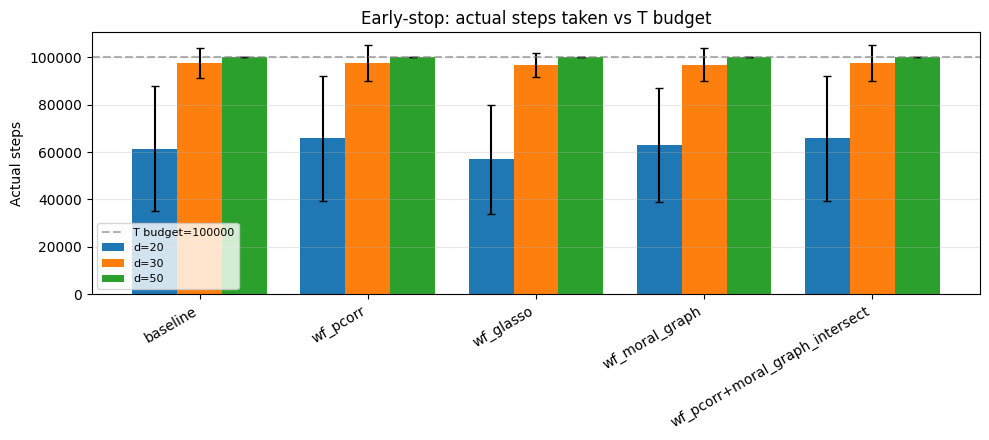

In [5]:
# 4b) Early-stop step comparison
if not CFG['early_stop'] or 'actual_steps' not in df_trials.columns:
    print('Early stopping disabled - no step data.')
else:
    algs = [v['label'] for v in VARIANTS if v['label'] in df_trials['algorithm'].unique()]
    d_vals = sorted(df_trials['d'].unique())

    print('=== Actual steps used (mean +/- std) ===')
    for alg in algs:
        for d_val in d_vals:
            s = df_trials[(df_trials['algorithm'] == alg) & (df_trials['d'] == d_val)]['actual_steps']
            if len(s) == 0:
                continue
            print(f'  {alg:30s}  d={d_val:3d}  steps: {s.mean():8.0f} +/- {s.std():7.0f}  (budget={CFG["T"]})')

    fig, ax = plt.subplots(figsize=(max(10, 1.5 * len(algs)), 4.5))
    x = np.arange(len(algs))
    width = 0.8 / max(len(d_vals), 1)
    for di, d_val in enumerate(d_vals):
        means = [df_trials[(df_trials['algorithm'] == a) & (df_trials['d'] == d_val)]['actual_steps'].mean() for a in algs]
        stds  = [df_trials[(df_trials['algorithm'] == a) & (df_trials['d'] == d_val)]['actual_steps'].std() for a in algs]
        ax.bar(x + (di - (len(d_vals)-1) / 2) * width, means, width, yerr=stds, capsize=3, label=f'd={d_val}')
    ax.axhline(CFG['T'], color='gray', linestyle='--', alpha=0.6, label=f'T budget={CFG["T"]}')
    ax.set_xticks(x)
    ax.set_xticklabels(algs, rotation=30, ha='right')
    ax.set_ylabel('Actual steps')
    ax.set_title('Early-stop: actual steps taken vs T budget')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [6]:
# 5) Save results
if len(df_trials) == 0:
    print('WARNING: no results collected.')
else:
    ts_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    trials_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{ts_str}.csv")
    summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{ts_str}.csv")
    latest_trials_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials.csv")
    latest_summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary.csv")

    df_trials.to_csv(trials_path, index=False)
    df_summary.to_csv(summary_path, index=False)
    df_trials.to_csv(latest_trials_path, index=False)
    df_summary.to_csv(latest_summary_path, index=False)

    print(f'Trials  saved to: {trials_path}')
    print(f'Summary saved to: {summary_path}')
    print(f'Rows: {len(df_trials)}  |  Skips: {len(skip_logs)}')

Trials  saved to: c:\Users\super\DAG\experiments\results\er_cd_A_weakfaith_benchmark_trials_20260511_231651.csv
Summary saved to: c:\Users\super\DAG\experiments\results\er_cd_A_weakfaith_benchmark_summary_20260511_231651.csv
Rows: 146  |  Skips: 4


In [7]:
# 6) Overall comparison (aggregated across d, n)
if len(df_trials) == 0:
    print('Run the previous cell first.')
else:
    agg_dict = dict(
        mec_match_mean=('mec_match', 'mean'),
        shd_mean=('shd', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
        runtime_sec_mean=('runtime_sec', 'mean'),
        trials=('trial_id', 'count'),
    )
    if 'actual_steps' in df_trials.columns:
        agg_dict['actual_steps_mean'] = ('actual_steps', 'mean')
    if 'mask_keep_ratio' in df_trials.columns:
        agg_dict['mask_keep_mean'] = ('mask_keep_ratio', 'mean')
    for col in sorted(c for c in df_trials.columns if c.startswith('mask_')):
        if col == 'mask_keep_ratio':
            continue
        if pd.api.types.is_numeric_dtype(df_trials[col]):
            agg_dict[f'{col}_mean'] = (col, 'mean')
    order = [v['label'] for v in VARIANTS]
    df_overall = (
        df_trials.groupby('algorithm', as_index=False).agg(**agg_dict)
    )
    df_overall['algorithm'] = pd.Categorical(df_overall['algorithm'], order, ordered=True)
    df_overall = df_overall.sort_values('algorithm').reset_index(drop=True)
    display(df_overall)

,algorithm,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials,actual_steps_mean,mask_keep_mean,mask_allowed_count_mean,mask_glasso_allowed_count_mean,...,mask_overlap_pcorr_moral_graph_overlap_ratio_mean,mask_overlap_pcorr_moral_graph_union_count_mean,mask_pcorr_allowed_count_mean,mask_pcorr_keep_ratio_mean,mask_pcorr_zero_count_mean,mask_pcorr_zero_ratio_mean,mask_tau_mean,mask_total_offdiag_mean,mask_zero_count_mean,mask_zero_ratio_mean
0,baseline,0.0,111.800000,112.333333,56.409289,30,86349.333333,1.000000,1233.333333,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.00,1233.333333,0.000000,0.000000
1,wf_pcorr,0.0,25.100000,26.933333,46.653481,30,87793.500000,0.271098,258.400000,NaN,...,NaN,NaN,258.4,0.271098,974.933333,0.728902,0.05,1233.333333,974.933333,0.728902
2,wf_glasso,0.0,45.653846,46.576923,41.778960,26,82135.192308,0.250555,202.769231,202.769231,...,NaN,NaN,NaN,NaN,NaN,NaN,0.05,1046.153846,843.384615,0.749445
3,wf_moral_graph,0.0,26.300000,27.200000,90.206031,30,86594.333333,0.294299,284.733333,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.05,1233.333333,948.600000,0.705701
4,wf_pcorr+moral_graph_intersect,0.0,25.100000,26.933333,87.651728,30,87793.500000,0.271098,258.400000,NaN,...,1.0,974.933333,258.4,0.271098,974.933333,0.728902,0.05,1233.333333,974.933333,0.728902


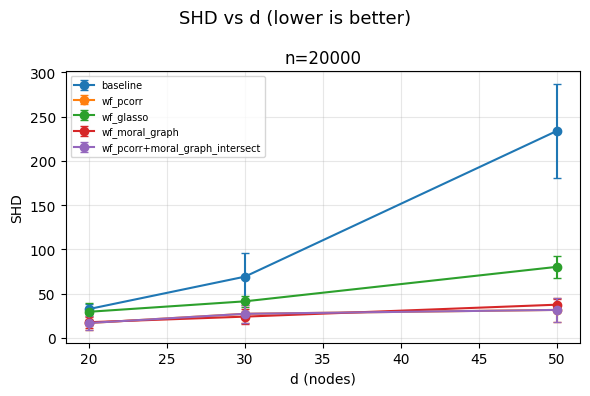

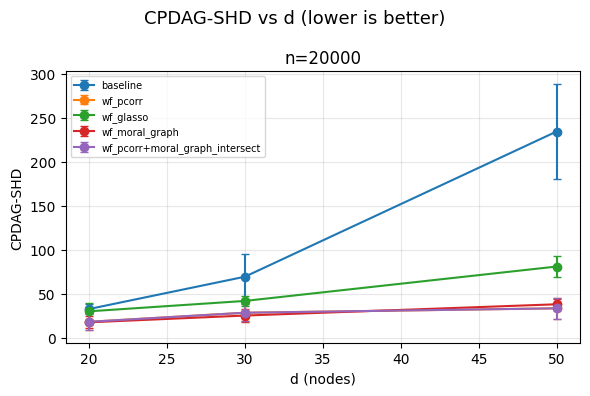

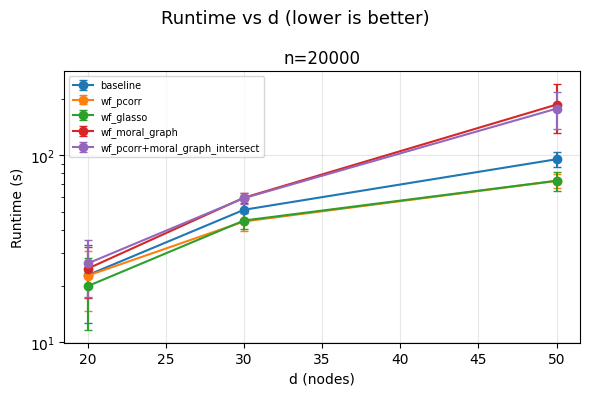

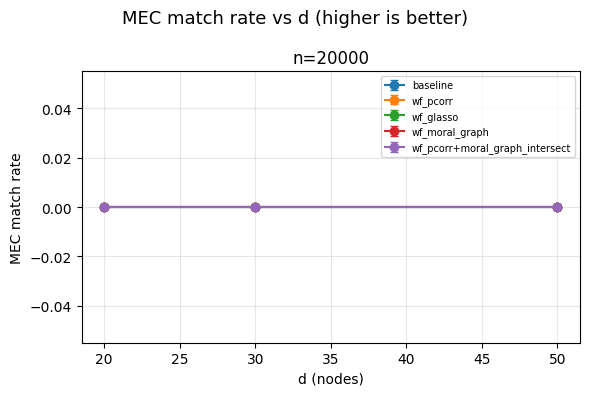

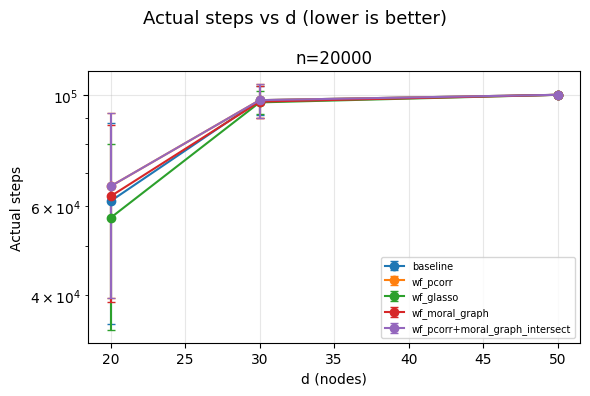

In [8]:
# 7) Plots: metric vs d across variants
if len(df_trials) == 0:
    print('Run the previous cell first.')
else:
    n_vals = sorted(df_trials['n_samples'].unique())
    algs = [v['label'] for v in VARIANTS if v['label'] in df_trials['algorithm'].unique()]
    color_map = {alg: f'C{i}' for i, alg in enumerate(algs)}

    metric_specs = [
        ('shd', 'SHD', 'SHD vs d (lower is better)', False),
        ('cpdag_shd', 'CPDAG-SHD', 'CPDAG-SHD vs d (lower is better)', False),
        ('runtime_sec', 'Runtime (s)', 'Runtime vs d (lower is better)', True),
        ('mec_match', 'MEC match rate', 'MEC match rate vs d (higher is better)', False),
    ]
    if 'actual_steps' in df_trials.columns:
        metric_specs.append(('actual_steps', 'Actual steps', 'Actual steps vs d (lower is better)', True))

    for metric, ylabel, title, log_y in metric_specs:
        fig, axes = plt.subplots(1, len(n_vals), figsize=(6 * len(n_vals), 4),
                                 sharey=True, squeeze=False)
        for ci, n in enumerate(n_vals):
            ax = axes[0][ci]
            sub = df_trials[df_trials['n_samples'] == n]
            agg = sub.groupby(['d', 'algorithm'])[metric].agg(['mean', 'std']).reset_index()
            for alg in algs:
                vals = agg[agg['algorithm'] == alg].sort_values('d')
                ax.errorbar(
                    vals['d'], vals['mean'], yerr=vals['std'].fillna(0.0),
                    marker='o', capsize=3, label=alg, color=color_map[alg],
                )
            ax.set_title(f'n={n}')
            ax.set_xlabel('d (nodes)')
            if ci == 0:
                ax.set_ylabel(ylabel)
            if log_y:
                ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=7, loc='best')
        fig.suptitle(title, fontsize=13)
        plt.tight_layout()
        plt.show()

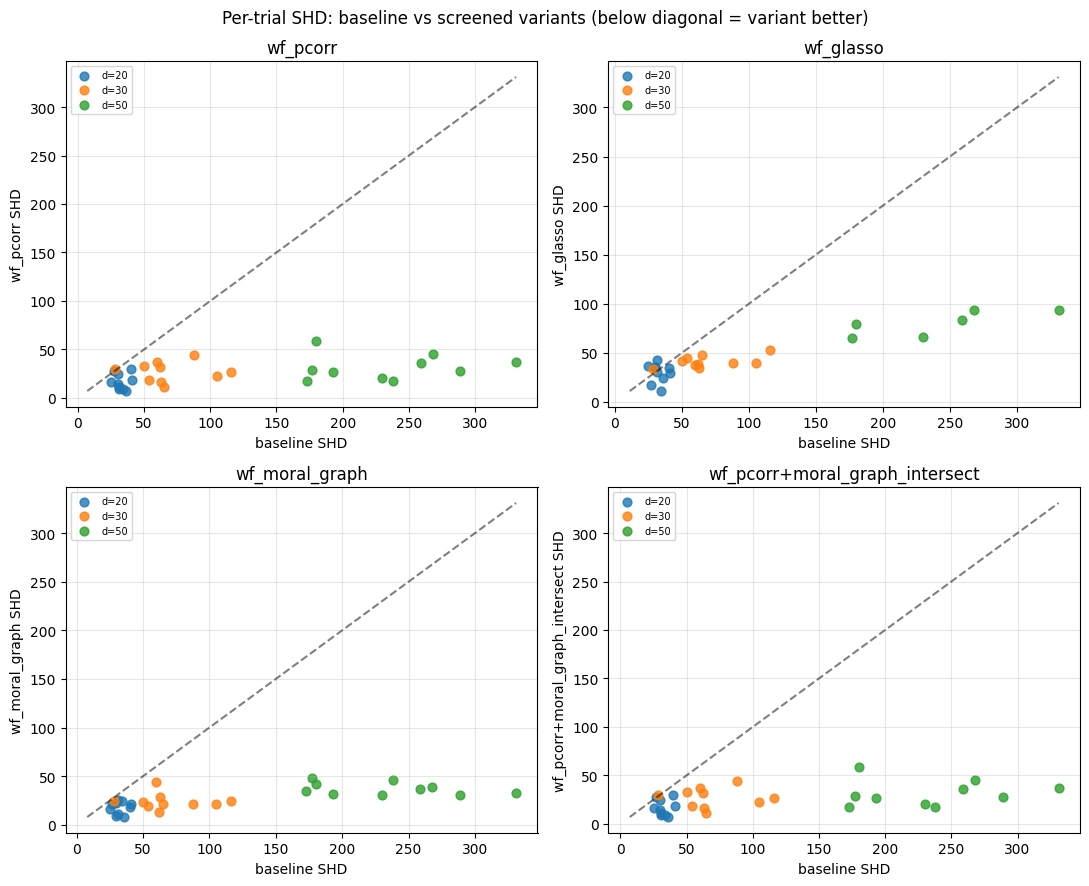

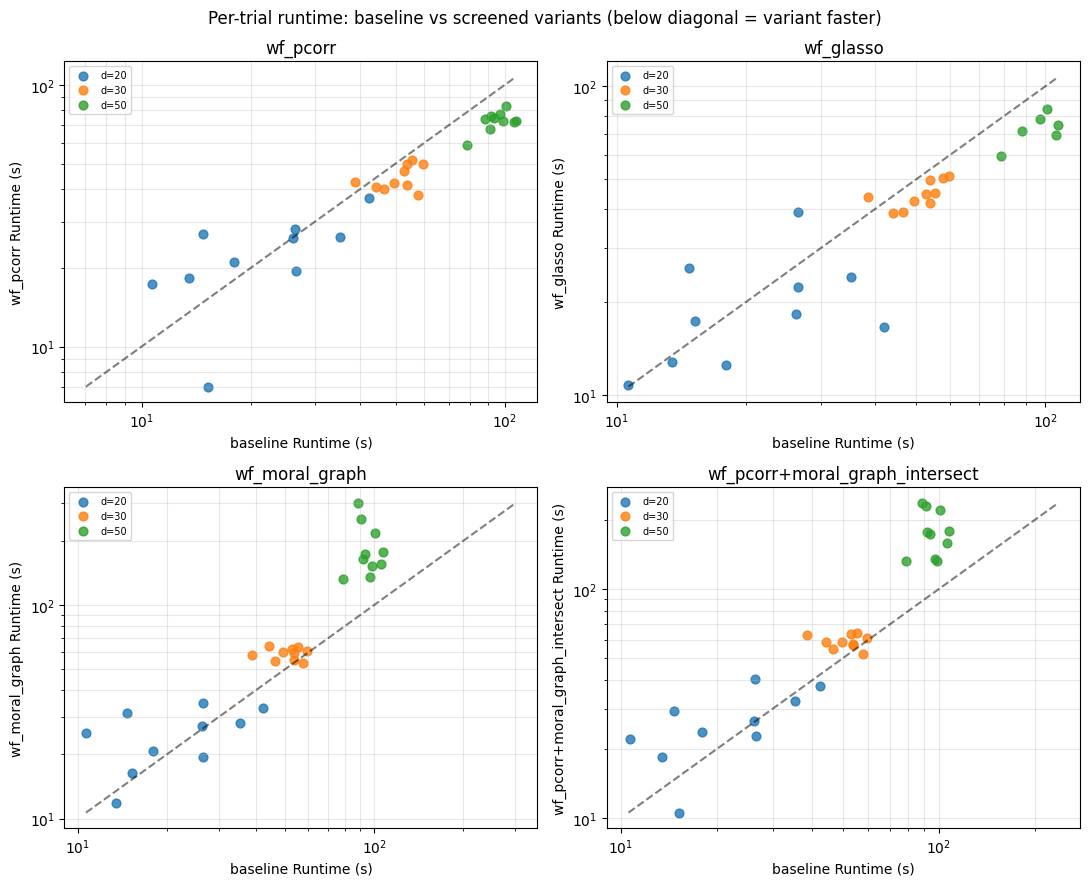

In [9]:
# 8) Per-trial paired scatter: baseline vs each screened variant
if len(df_trials) == 0:
    print('Run the previous cell first.')
else:
    baseline_label = 'baseline'
    wf_labels = [v['label'] for v in VARIANTS if v['kind'] == 'weakfaith'
                 and v['label'] in df_trials['algorithm'].unique()]

    if baseline_label not in df_trials['algorithm'].unique():
        print('Baseline missing; skipping paired scatters.')
    else:
        pivot_shd = df_trials.pivot_table(
            index=['d', 'n_samples', 'trial_id'], columns='algorithm', values='shd').reset_index()
        pivot_rt = df_trials.pivot_table(
            index=['d', 'n_samples', 'trial_id'], columns='algorithm', values='runtime_sec').reset_index()

        n_cols = 2
        n_rows = (len(wf_labels) + n_cols - 1) // n_cols
        for metric_name, pivot, title, log_axes in [
            ('SHD', pivot_shd, 'Per-trial SHD: baseline vs screened variants (below diagonal = variant better)', False),
            ('Runtime (s)', pivot_rt, 'Per-trial runtime: baseline vs screened variants (below diagonal = variant faster)', True),
        ]:
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.5 * n_rows), squeeze=False)
            for i, wf in enumerate(wf_labels):
                ax = axes[i // n_cols][i % n_cols]
                if wf not in pivot.columns:
                    ax.set_visible(False)
                    continue
                xs = pivot[baseline_label].values
                ys = pivot[wf].values
                ds = pivot['d'].values
                for di, d_val in enumerate(sorted(np.unique(ds))):
                    mask = ds == d_val
                    ax.scatter(xs[mask], ys[mask], s=40, alpha=0.8,
                               label=f'd={d_val}', color=f'C{di}')
                lo = np.nanmin(np.concatenate([xs, ys]))
                hi = np.nanmax(np.concatenate([xs, ys]))
                if log_axes:
                    ax.set_xscale('log'); ax.set_yscale('log')
                    lo = max(lo, 1e-3)
                ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5)
                ax.set_xlabel(f'baseline {metric_name}')
                ax.set_ylabel(f'{wf} {metric_name}')
                ax.set_title(wf)
                ax.grid(True, alpha=0.3, which='both')
                ax.legend(fontsize=7)
            for j in range(len(wf_labels), n_rows * n_cols):
                axes[j // n_cols][j % n_cols].set_visible(False)
            fig.suptitle(title, fontsize=12)
            plt.tight_layout()
            plt.show()

Mean mask keep ratio (M / d(d-1)) across trials:


algorithm,wf_glasso,wf_moral_graph,wf_pcorr,wf_pcorr+moral_graph_intersect
d,,,,
20,0.333158,0.419474,0.390526,0.390526
30,0.240000,0.278851,0.258851,0.258851
50,0.130476,0.184571,0.163918,0.163918


Mean masked-zero counts/ratios across trials:


,algorithm,d,mask_zero_count,mask_zero_ratio,mask_pcorr_zero_count,mask_pcorr_zero_ratio,mask_glasso_zero_count,mask_glasso_zero_ratio
0,wf_glasso,20,253.400000,0.666842,NaN,NaN,253.400000,0.666842
1,wf_glasso,30,661.200000,0.760000,NaN,NaN,661.200000,0.760000
2,wf_glasso,50,2130.333333,0.869524,NaN,NaN,2130.333333,0.869524
3,wf_moral_graph,20,220.600000,0.580526,NaN,NaN,NaN,NaN
4,wf_moral_graph,30,627.400000,0.721149,NaN,NaN,NaN,NaN
5,wf_moral_graph,50,1997.800000,0.815429,NaN,NaN,NaN,NaN
6,wf_pcorr,20,231.600000,0.609474,231.6,0.609474,NaN,NaN
7,wf_pcorr,30,644.800000,0.741149,644.8,0.741149,NaN,NaN
8,wf_pcorr,50,2048.400000,0.836082,2048.4,0.836082,NaN,NaN
9,wf_pcorr+moral_graph_intersect,20,231.600000,0.609474,231.6,0.609474,NaN,NaN


Mean pairwise/all masked-set overlap across trials:


,algorithm,d,mask_overlap_pcorr_moral_graph_count,mask_overlap_pcorr_moral_graph_union_count,mask_overlap_pcorr_moral_graph_jaccard,mask_overlap_pcorr_moral_graph_overlap_ratio,mask_overlap_all_count,mask_overlap_all_union_count,mask_overlap_all_jaccard
0,wf_glasso,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,wf_glasso,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,wf_glasso,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,wf_moral_graph,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,wf_moral_graph,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,wf_moral_graph,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,wf_pcorr,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,wf_pcorr,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,wf_pcorr,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,wf_pcorr+moral_graph_intersect,20,220.6,231.6,0.952695,1.0,220.6,231.6,0.952695


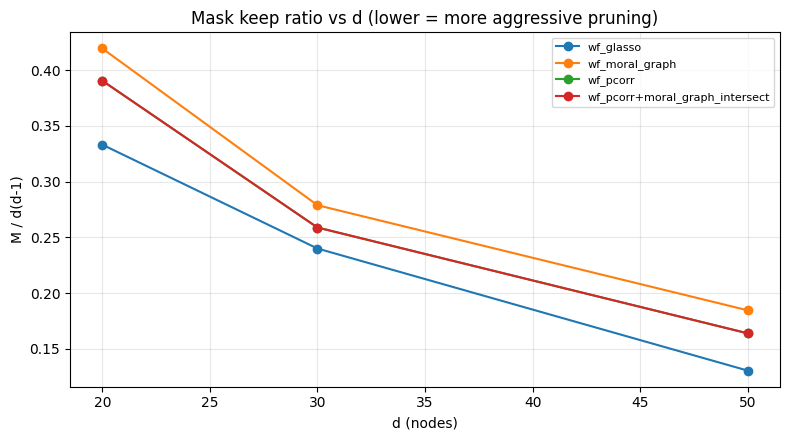

In [10]:
# 9) Mask diagnostics: sparsity, zero counts, and overlap across variants and d
if 'mask_keep_ratio' not in df_trials.columns:
    print('No mask_keep_ratio column.')
else:
    wf_sub = df_trials[df_trials['algorithm'] != 'baseline']
    pivot = wf_sub.pivot_table(
        index='d', columns='algorithm', values='mask_keep_ratio', aggfunc='mean',
    )
    print('Mean mask keep ratio (M / d(d-1)) across trials:')
    display(pivot)

    zero_cols = [
        c for c in [
            'mask_zero_count', 'mask_zero_ratio',
            'mask_corr_zero_count', 'mask_corr_zero_ratio',
            'mask_pcorr_zero_count', 'mask_pcorr_zero_ratio',
            'mask_glasso_zero_count', 'mask_glasso_zero_ratio',
            'mask_initial_gain_zero_count', 'mask_initial_gain_zero_ratio',
            'mask_initial_gain_allowed_count', 'mask_initial_gain_keep_ratio',
        ] if c in wf_sub.columns
    ]
    if zero_cols:
        zero_summary = wf_sub.groupby(['algorithm', 'd'], as_index=False)[zero_cols].mean()
        print('Mean masked-zero counts/ratios across trials:')
        display(zero_summary)

    overlap_cols = [c for c in wf_sub.columns if c.startswith('mask_overlap_')]
    if overlap_cols:
        overlap_summary = wf_sub.groupby(['algorithm', 'd'], as_index=False)[overlap_cols].mean()
        print('Mean pairwise/all masked-set overlap across trials:')
        display(overlap_summary)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for alg in pivot.columns:
        ax.plot(pivot.index, pivot[alg], marker='o', label=alg)
    ax.set_xlabel('d (nodes)')
    ax.set_ylabel('M / d(d-1)')
    ax.set_title('Mask keep ratio vs d (lower = more aggressive pruning)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [11]:
# 10) Skip log
if skip_logs:
    display(pd.DataFrame(skip_logs))
else:
    print('No skips.')

,algorithm,d,n_samples,trial_id,reason
0,wf_glasso,50,20000,1,"mask fully empty for (('glasso',), 'union', 0...."
1,wf_glasso,50,20000,2,"mask fully empty for (('glasso',), 'union', 0...."
2,wf_glasso,50,20000,7,"mask fully empty for (('glasso',), 'union', 0...."
3,wf_glasso,50,20000,9,"mask fully empty for (('glasso',), 'union', 0...."


## Section B — Tau sensitivity scan

Isolates the effect of the screening threshold $\tau$ from the choice of
screen. For each selected screen configuration (single or combined), $\tau$
is swept over a range. The baseline (no screening) is included as a
reference line on every plot.

By default this scan restricts to a single $d$ to keep runtime tight; edit
`CFG_TAU['d_list']` if you want the full scan across dimensions.

In [12]:
# B2) Section B config ? tau sensitivity scan
# Inherit Section A config; narrow d to a single dim and fix one sampling_mode.
CFG_TAU = dict(CFG)
CFG_TAU['tag'] = 'er_cd_A_weakfaith_tau_scan'
CFG_TAU['d_list'] = [30]
CFG_TAU['trials'] = 10

TAU_VALUES = [0.02, 0.05, 0.1, 0.2]
# Representative screen configurations to sweep tau over. Combined screens use
# combine='intersect' so an edge is masked if any selected screen marks it zero.
TAU_SCAN_SCREENS = [
    ('corr',         ['corr'],            'union'),
    ('pcorr',        ['pcorr'],           'union'),
    ('glasso',       ['glasso'],          'union'),
    ('corr+pcorr',   ['corr', 'pcorr'],   COMBINE_MODE),
    ('corr+glasso',  ['corr', 'glasso'],  COMBINE_MODE),
]

VARIANTS_TAU = [{'label': 'baseline', 'kind': 'baseline'}]
for sc_name, sc_list, combine in TAU_SCAN_SCREENS:
    for tau in TAU_VALUES:
        VARIANTS_TAU.append({
            'label': f'wf_{sc_name}_tau{tau}_{combine}',
            'kind': 'weakfaith',
            'screening': sc_list,
            'tau': tau,
            'sampling_mode': SAMPLING_MODE,
            'combine': combine,
        })

print('Section B (tau scan) config ready.')
print(f"  d_list     : {CFG_TAU['d_list']}")
print(f"  trials     : {CFG_TAU['trials']}")
print(f"  tau values : {TAU_VALUES}")
print(f"  screens    : {[(s[0], s[2]) for s in TAU_SCAN_SCREENS]}")
print(f"  variants   : {len(VARIANTS_TAU)}")
for v in VARIANTS_TAU:
    print(f"    - {v['label']}")


Section B (tau scan) config ready.
  d_list     : [30]
  trials     : 10
  tau values : [0.02, 0.05, 0.1, 0.2]
  screens    : [('corr', 'union'), ('pcorr', 'union'), ('glasso', 'union'), ('corr+pcorr', 'intersect'), ('corr+glasso', 'intersect')]
  variants   : 21
    - baseline
    - wf_corr_tau0.02_union
    - wf_corr_tau0.05_union
    - wf_corr_tau0.1_union
    - wf_corr_tau0.2_union
    - wf_pcorr_tau0.02_union
    - wf_pcorr_tau0.05_union
    - wf_pcorr_tau0.1_union
    - wf_pcorr_tau0.2_union
    - wf_glasso_tau0.02_union
    - wf_glasso_tau0.05_union
    - wf_glasso_tau0.1_union
    - wf_glasso_tau0.2_union
    - wf_corr+pcorr_tau0.02_intersect
    - wf_corr+pcorr_tau0.05_intersect
    - wf_corr+pcorr_tau0.1_intersect
    - wf_corr+pcorr_tau0.2_intersect
    - wf_corr+glasso_tau0.02_intersect
    - wf_corr+glasso_tau0.05_intersect
    - wf_corr+glasso_tau0.1_intersect
    - wf_corr+glasso_tau0.2_intersect


In [ ]:
# B3) Run tau scan
df_tau, skip_tau = run_variants(VARIANTS_TAU, CFG_TAU)
df_tau_summary = summarize(df_tau)

print('\nPer-(algorithm, d, n) summary:')
display(df_tau_summary)

[baseline                    ] d=30 n=20000 trial=1  mec=0  shd=120  cpdag_shd=118  rt=45.048s  steps=100000  keep=1.00
[wf_corr_tau0.02_union       ] d=30 n=20000 trial=1  mec=0  shd=104  cpdag_shd=104  rt=39.729s  steps=100000  keep=0.63
[wf_corr_tau0.05_union       ] d=30 n=20000 trial=1  mec=0  shd=79  cpdag_shd=77  rt=37.312s  steps=100000  keep=0.61
[wf_corr_tau0.1_union        ] d=30 n=20000 trial=1  mec=0  shd=77  cpdag_shd=77  rt=39.439s  steps=100000  keep=0.57
[wf_corr_tau0.2_union        ] d=30 n=20000 trial=1  mec=0  shd=94  cpdag_shd=94  rt=41.981s  steps=100000  keep=0.49
[wf_pcorr_tau0.02_union      ] d=30 n=20000 trial=1  mec=0  shd=43  cpdag_shd=43  rt=39.796s  steps=100000  keep=0.30
[wf_pcorr_tau0.05_union      ] d=30 n=20000 trial=1  mec=0  shd=39  cpdag_shd=39  rt=43.513s  steps=100000  keep=0.29
[wf_pcorr_tau0.1_union       ] d=30 n=20000 trial=1  mec=0  shd=46  cpdag_shd=48  rt=44.132s  steps=100000  keep=0.25
[wf_pcorr_tau0.2_union       ] d=30 n=20000 trial=1 

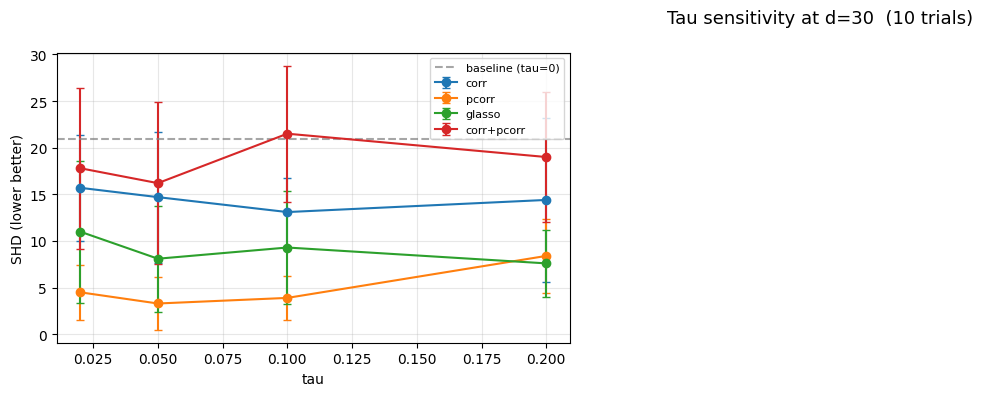

In [ ]:
# B4) Tau effect plots
if len(df_tau) == 0:
    print('Run B2 first.')
else:
    # Attach (screen_group, tau_val) to each row from VARIANTS_TAU.
    label_meta = {}
    for v in VARIANTS_TAU:
        if v['kind'] == 'baseline':
            label_meta[v['label']] = {'screen_group': 'baseline', 'tau_val': 0.0}
        else:
            names = v['screening'] if isinstance(v['screening'], list) else [v['screening']]
            label_meta[v['label']] = {'screen_group': '+'.join(names),
                                      'tau_val': float(v['tau'])}

    df_plot = df_tau.copy()
    df_plot['screen_group'] = df_plot['algorithm'].map(lambda a: label_meta[a]['screen_group'])
    df_plot['tau_val'] = df_plot['algorithm'].map(lambda a: label_meta[a]['tau_val'])

    wf_groups = [name for name, _, _ in TAU_SCAN_SCREENS]
    color_map = {g: f'C{i}' for i, g in enumerate(wf_groups)}

    metric_specs = [
        ('shd', 'SHD (lower better)', False),
    ]

    baseline_sub = df_plot[df_plot['screen_group'] == 'baseline']

    d_vals = sorted(df_plot['d'].unique())
    for d_val in d_vals:
        dfd = df_plot[df_plot['d'] == d_val]
        n_metrics = len(metric_specs)
        n_cols = 3
        n_rows = (n_metrics + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4 * n_rows),
                                 squeeze=False)
        for mi, (metric, ylabel, log_y) in enumerate(metric_specs):
            ax = axes[mi // n_cols][mi % n_cols]
            for g in wf_groups:
                sub = dfd[dfd['screen_group'] == g]
                if len(sub) == 0:
                    continue
                agg = sub.groupby('tau_val')[metric].agg(['mean', 'std']).reset_index()
                ax.errorbar(agg['tau_val'], agg['mean'], yerr=agg['std'].fillna(0.0),
                            marker='o', capsize=3, label=g, color=color_map[g])
            # Baseline reference (tau=0, no screening)
            base_mean = baseline_sub[baseline_sub['d'] == d_val][metric].mean()
            if not np.isnan(base_mean):
                ax.axhline(base_mean, color='gray', linestyle='--', alpha=0.7,
                           label='baseline (tau=0)')
            ax.set_xlabel('tau')
            ax.set_ylabel(ylabel)
            if log_y:
                ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
        for j in range(n_metrics, n_rows * n_cols):
            axes[j // n_cols][j % n_cols].set_visible(False)
        fig.suptitle(f'Tau sensitivity at d={d_val}  ({CFG_TAU["trials"]} trials)',
                     fontsize=13)
        plt.tight_layout()
        plt.show()

In [ ]:
# B5) Save tau-scan results
if len(df_tau) == 0:
    print('WARNING: no tau-scan results collected.')
else:
    ts_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    trials_path = os.path.join(CFG_TAU['out_dir'], f"{CFG_TAU['tag']}_trials_{ts_str}.csv")
    summary_path = os.path.join(CFG_TAU['out_dir'], f"{CFG_TAU['tag']}_summary_{ts_str}.csv")
    latest_trials = os.path.join(CFG_TAU['out_dir'], f"{CFG_TAU['tag']}_trials.csv")
    latest_summary = os.path.join(CFG_TAU['out_dir'], f"{CFG_TAU['tag']}_summary.csv")

    df_tau.to_csv(trials_path, index=False)
    df_tau_summary.to_csv(summary_path, index=False)
    df_tau.to_csv(latest_trials, index=False)
    df_tau_summary.to_csv(latest_summary, index=False)

    print(f'Trials  : {trials_path}')
    print(f'Summary : {summary_path}')
    print(f'Rows: {len(df_tau)}  |  Skips: {len(skip_tau)}')

Trials  : c:\Users\super\DAG\experiments\results\er_cd_A_weakfaith_tau_scan_trials_20260425_231130.csv
Summary : c:\Users\super\DAG\experiments\results\er_cd_A_weakfaith_tau_scan_summary_20260425_231130.csv
Rows: 170  |  Skips: 0
